In [1]:
#import library and ignore warning
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
#laod dataset
data_preprocessed = pd.read_csv('../data/preprocessed/clean_Absenteeism_data.csv')

In [3]:
data_preprocessed.head()

,reason_1,reason_2,reason_3,reason_4,month_value,day_of_the_week,transportation_expense,distance_to_work,age,daily_work_load_average,body_mass_index,education,children,pets,absenteeism_time_in_hours
0,0,0,0,1,7,1,289,36,33,239.554,30,0,2,1,4
1,0,0,0,0,7,1,118,13,50,239.554,31,0,1,0,0
2,0,0,0,1,7,2,179,51,38,239.554,31,0,0,0,2
3,1,0,0,0,7,3,279,5,39,239.554,24,0,2,0,4
4,0,0,0,1,7,3,289,36,33,239.554,30,0,2,1,2


In [4]:
#create target
data_preprocessed['absenteeism_time_in_hours'].median()

3.0

In [14]:
targets = np.where(data_preprocessed['absenteeism_time_in_hours'] >
                   data_preprocessed['absenteeism_time_in_hours'].median(), 1, 0)
targets[range(5)]

array([1, 0, 0, 1, 0])

In [15]:
data_preprocessed['excessive_absenteeism'] = targets
data_preprocessed.head()

,reason_1,reason_2,reason_3,reason_4,month_value,day_of_the_week,transportation_expense,distance_to_work,age,daily_work_load_average,body_mass_index,education,children,pets,absenteeism_time_in_hours,excessive_absenteeism
0,0,0,0,1,7,1,289,36,33,239.554,30,0,2,1,4,1
1,0,0,0,0,7,1,118,13,50,239.554,31,0,1,0,0,0
2,0,0,0,1,7,2,179,51,38,239.554,31,0,0,0,2,0
3,1,0,0,0,7,3,279,5,39,239.554,24,0,2,0,4,1
4,0,0,0,1,7,3,289,36,33,239.554,30,0,2,1,2,0


In [16]:
targets.sum() / targets.shape[0]

np.float64(0.45571428571428574)

In [17]:
data_with_targets = data_preprocessed.drop(['absenteeism_time_in_hours', 'day_of_the_week', 
                                            'distance_to_work', 'daily_work_load_average' ], axis=1)

In [18]:
#check if it the same
data_with_targets is data_preprocessed

False

In [19]:
data_with_targets.head()

,reason_1,reason_2,reason_3,reason_4,month_value,transportation_expense,age,body_mass_index,education,children,pets,excessive_absenteeism
0,0,0,0,1,7,289,33,30,0,2,1,1
1,0,0,0,0,7,118,50,31,0,1,0,0
2,0,0,0,1,7,179,38,31,0,0,0,0
3,1,0,0,0,7,279,39,24,0,2,0,1
4,0,0,0,1,7,289,33,30,0,2,1,0


In [20]:
#select the inputs for the regression
data_with_targets.shape

(700, 12)

In [21]:
data_with_targets.iloc[:, :-1]

,reason_1,reason_2,reason_3,reason_4,month_value,transportation_expense,age,body_mass_index,education,children,pets
0,0,0,0,1,7,289,33,30,0,2,1
1,0,0,0,0,7,118,50,31,0,1,0
2,0,0,0,1,7,179,38,31,0,0,0
3,1,0,0,0,7,279,39,24,0,2,0
4,0,0,0,1,7,289,33,30,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
695,1,0,0,0,5,179,40,22,1,2,0
696,1,0,0,0,5,225,28,24,0,1,2
697,1,0,0,0,5,330,28,25,1,0,0
698,0,0,0,1,5,235,32,25,1,0,0


In [22]:
unscaled_inputs = data_with_targets.iloc[:, :-1]

In [23]:
#Standardize the data
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self, columns, copy=True, with_mean=True, with_std=True):
        self.columns = columns
        self.copy = copy
        self.with_mean = with_mean
        self.with_std = with_std
        self.scaler = StandardScaler(copy=copy, with_mean=with_mean, with_std=with_std)
        self.mean_ = None
        self.var_ = None

    def fit(self, X, y=None):
        self.scaler.fit(X[self.columns], y)
        self.mean_ = np.mean(X[self.columns])
        self.var_ = np.var(X[self.columns])
        return self

    def transform(self, X, y=None, copy=None):
        init_col_order = X.columns
        X_scaled = pd.DataFrame(self.scaler.transform(X[self.columns]), columns=self.columns)
        X_not_scaled = X.loc[:, ~X.columns.isin(self.columns)]
        return pd.concat([X_not_scaled, X_scaled], axis=1)[init_col_order]

#scalar = StandardScaler()

In [24]:
unscaled_inputs.columns.values

array(['reason_1', 'reason_2', 'reason_3', 'reason_4', 'month_value',
       'transportation_expense', 'age', 'body_mass_index', 'education',
       'children', 'pets'], dtype=object)

In [25]:
#do not scale the reason_1-3 and education as it dummie

#columns_to_scale = ['transportation_expense', 'distance_to_work', 'age',
       #'daily_work_load_average', 'body_mass_index',
       #'children', 'pets', 'month_value', 'day_of_the_week']

columns_to_omit = ['reason_1', 'reason_2', 'reason_3', 'reason_4', 'education' ]

In [26]:
columns_to_scale = [x for x in unscaled_inputs.columns.values if x not in columns_to_omit]

In [27]:
#apply function to scale only needed columns
scalar = CustomScaler(columns_to_scale)

In [28]:
scalar.fit(unscaled_inputs)

,columns,"['month_value', 'transportation_expense', ...]"
,copy,True
,with_mean,True
,with_std,True


In [29]:
# .tranform() dose the actual scaling
scaled_inputs = scalar.transform(unscaled_inputs)

In [30]:
scaled_inputs

,reason_1,reason_2,reason_3,reason_4,month_value,transportation_expense,age,body_mass_index,education,children,pets
0,0,0,0,1,0.182726,1.005844,-0.536062,0.767431,0,0.880469,0.268487
1,0,0,0,0,0.182726,-1.574681,2.130803,1.002633,0,-0.019280,-0.589690
2,0,0,0,1,0.182726,-0.654143,0.248310,1.002633,0,-0.919030,-0.589690
3,1,0,0,0,0.182726,0.854936,0.405184,-0.643782,0,0.880469,-0.589690
4,0,0,0,1,0.182726,1.005844,-0.536062,0.767431,0,0.880469,0.268487
...,...,...,...,...,...,...,...,...,...,...,...
695,1,0,0,0,-0.388293,-0.654143,0.562059,-1.114186,1,0.880469,-0.589690
696,1,0,0,0,-0.388293,0.040034,-1.320435,-0.643782,0,-0.019280,1.126663
697,1,0,0,0,-0.388293,1.624567,-1.320435,-0.408580,1,-0.919030,-0.589690
698,0,0,0,1,-0.388293,0.190942,-0.692937,-0.408580,1,-0.919030,-0.589690


In [31]:
scaled_inputs.describe().round(2)

,reason_1,reason_2,reason_3,reason_4,month_value,transportation_expense,age,body_mass_index,education,children,pets
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,0.25,0.01,0.09,0.60,-0.00,-0.00,0.00,0.00,0.17,0.00,-0.00
std,0.43,0.09,0.29,0.49,1.00,1.00,1.00,1.00,0.37,1.00,1.00
min,0.00,0.00,0.00,0.00,-1.53,-1.57,-1.48,-1.82,0.00,-0.92,-0.59
25%,0.00,0.00,0.00,0.00,-0.96,-0.65,-0.85,-0.64,0.00,-0.92,-0.59
50%,0.00,0.00,0.00,1.00,-0.10,0.04,0.09,-0.41,0.00,-0.02,-0.59
75%,0.25,0.00,0.00,1.00,1.04,0.57,0.56,1.00,0.00,0.88,0.27
max,1.00,1.00,1.00,1.00,1.61,2.50,3.39,2.65,1.00,2.68,6.28


In [32]:
scaled_inputs.shape

(700, 11)

In [33]:
#split the data into training and testing 
from sklearn.model_selection import train_test_split

In [34]:
#train dataset
x_train, x_test, y_train, y_test = train_test_split(scaled_inputs, targets,
                                                   train_size=0.8, random_state=42)

In [35]:
print(x_train.shape, y_train.shape)

(560, 11) (560,)


In [38]:
#logistic regression with sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
reg = LogisticRegression()

In [40]:
reg.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
reg.score(x_train, y_train)

0.7732142857142857

In [42]:
#manually check the accuracy 
model_outputs = reg.predict(x_train)
model_outputs[range(10)]

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [43]:
y_train[range(10)]

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 1])

In [48]:
#mentually calculate the accuracy of the model
print('In Training Dataset')
print(f'Total of Currect out of all predicted: {np.sum(model_outputs == y_train)}')
print(f'Number of predicted: {model_outputs.shape[0]}')
print(f'Accuracy: {np.sum(model_outputs == y_train) / model_outputs.shape[0]}')


In Training Dataset
Total of Currect out of all predicted: 433
Number of predicted: 560
Accuracy: 0.7732142857142857


In [49]:
#finding the intercept and coefficient 
reg.intercept_
#like the initial values

array([-1.70293007])

In [50]:
reg.coef_
#the x of each features

array([[ 2.9136209 ,  0.75484748,  3.09891742,  0.96486444,  0.07441017,
         0.65018629, -0.25112372,  0.25250206, -0.24004052,  0.39910996,
        -0.29389223]])

In [52]:
scaled_inputs.head()

,reason_1,reason_2,reason_3,reason_4,month_value,transportation_expense,age,body_mass_index,education,children,pets
0,0,0,0,1,0.182726,1.005844,-0.536062,0.767431,0,0.880469,0.268487
1,0,0,0,0,0.182726,-1.574681,2.130803,1.002633,0,-0.019280,-0.589690
2,0,0,0,1,0.182726,-0.654143,0.248310,1.002633,0,-0.919030,-0.589690
3,1,0,0,0,0.182726,0.854936,0.405184,-0.643782,0,0.880469,-0.589690
4,0,0,0,1,0.182726,1.005844,-0.536062,0.767431,0,0.880469,0.268487


In [53]:
#get the features name
feature_name = unscaled_inputs.columns.values

In [54]:
summary_table = pd.DataFrame(columns=['feature_name'], data=feature_name)
summary_table

,feature_name
0,reason_1
1,reason_2
2,reason_3
3,reason_4
4,month_value
5,transportation_expense
6,age
7,body_mass_index
8,education
9,children


In [55]:
#put the data as a columns
summary_table['coefficient'] = np.transpose(reg.coef_)
summary_table

,feature_name,coefficient
0,reason_1,2.913621
1,reason_2,0.754847
2,reason_3,3.098917
3,reason_4,0.964864
4,month_value,0.074410
5,transportation_expense,0.650186
6,age,-0.251124
7,body_mass_index,0.252502
8,education,-0.240041
9,children,0.399110


In [56]:
summary_table.index = summary_table.index + 1
summary_table

,feature_name,coefficient
1,reason_1,2.913621
2,reason_2,0.754847
3,reason_3,3.098917
4,reason_4,0.964864
5,month_value,0.074410
6,transportation_expense,0.650186
7,age,-0.251124
8,body_mass_index,0.252502
9,education,-0.240041
10,children,0.399110


In [57]:
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table

,feature_name,coefficient
1,reason_1,2.913621
2,reason_2,0.754847
3,reason_3,3.098917
4,reason_4,0.964864
5,month_value,0.074410
6,transportation_expense,0.650186
7,age,-0.251124
8,body_mass_index,0.252502
9,education,-0.240041
10,children,0.399110


In [58]:
summary_table = summary_table.sort_index()
summary_table

,feature_name,coefficient
0,Intercept,-1.702930
1,reason_1,2.913621
2,reason_2,0.754847
3,reason_3,3.098917
4,reason_4,0.964864
5,month_value,0.074410
6,transportation_expense,0.650186
7,age,-0.251124
8,body_mass_index,0.252502
9,education,-0.240041


In [59]:
summary_table['coefficient'] = pd.to_numeric(summary_table['coefficient'])
summary_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   feature_name  12 non-null     object 
 1   coefficient   12 non-null     float64
dtypes: float64(1), object(1)
memory usage: 288.0+ bytes


In [60]:
#interpreting the coefficient
summary_table['odds_ratio'] = np.exp(summary_table.coefficient)

In [61]:
summary_table.sort_values('odds_ratio', ascending=False)

,feature_name,coefficient,odds_ratio
3,reason_3,3.098917,22.173933
1,reason_1,2.913621,18.423387
4,reason_4,0.964864,2.624432
2,reason_2,0.754847,2.127287
6,transportation_expense,0.650186,1.915898
10,children,0.399110,1.490498
8,body_mass_index,0.252502,1.287242
5,month_value,0.074410,1.077249
9,education,-0.240041,0.786596
7,age,-0.251124,0.777926


In [51]:
#backward elimination
#reduce some features that nearly to 0

In [62]:
#testing the model
reg.score(x_test, y_test)

0.7714285714285715

Logistic Regression - Detailed Metrics:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        82
           1       0.73      0.71      0.72        58

    accuracy                           0.77       140
   macro avg       0.76      0.76      0.76       140
weighted avg       0.77      0.77      0.77       140



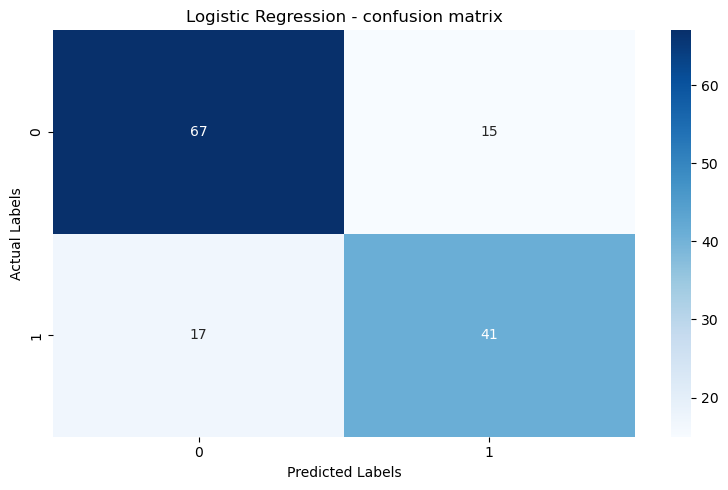

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Detailed results for one model
y_pred = reg.predict(x_test)

print("Logistic Regression - Detailed Metrics:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1],
            yticklabels=[0, 1])

plt.title("Logistic Regression - confusion matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.tight_layout()
plt.show()

In [69]:
predicted_proba = reg.predict_proba(x_test)
predicted_proba
#first columns represent 0 and last is 1

array([[0.82957126, 0.17042874],
       [0.85163998, 0.14836002],
       [0.79779583, 0.20220417],
       [0.593212  , 0.406788  ],
       [0.57365867, 0.42634133],
       [0.08041824, 0.91958176],
       [0.67595129, 0.32404871],
       [0.35568421, 0.64431579],
       [0.7163203 , 0.2836797 ],
       [0.74005176, 0.25994824],
       [0.86456635, 0.13543365],
       [0.67492732, 0.32507268],
       [0.26570587, 0.73429413],
       [0.44925745, 0.55074255],
       [0.72600362, 0.27399638],
       [0.4921817 , 0.5078183 ],
       [0.89459595, 0.10540405],
       [0.21441612, 0.78558388],
       [0.86703473, 0.13296527],
       [0.58401659, 0.41598341],
       [0.73026575, 0.26973425],
       [0.74411785, 0.25588215],
       [0.68178599, 0.31821401],
       [0.67957102, 0.32042898],
       [0.86082189, 0.13917811],
       [0.16084394, 0.83915606],
       [0.59430082, 0.40569918],
       [0.59675531, 0.40324469],
       [0.75996029, 0.24003971],
       [0.59941268, 0.40058732],
       [0.

In [70]:
predicted_proba.shape

(140, 2)

In [71]:
predicted_proba[:,1]

array([0.17042874, 0.14836002, 0.20220417, 0.406788  , 0.42634133,
       0.91958176, 0.32404871, 0.64431579, 0.2836797 , 0.25994824,
       0.13543365, 0.32507268, 0.73429413, 0.55074255, 0.27399638,
       0.5078183 , 0.10540405, 0.78558388, 0.13296527, 0.41598341,
       0.26973425, 0.25588215, 0.31821401, 0.32042898, 0.13917811,
       0.83915606, 0.40569918, 0.40324469, 0.24003971, 0.40058732,
       0.11740629, 0.14127068, 0.59939433, 0.56123137, 0.27824269,
       0.64991631, 0.31821401, 0.13371416, 0.85473685, 0.19918143,
       0.518433  , 0.25185802, 0.63451971, 0.12814276, 0.2248817 ,
       0.72597901, 0.76889861, 0.88389353, 0.30906773, 0.13053509,
       0.25994824, 0.31362277, 0.42634133, 0.93283814, 0.13871298,
       0.2248817 , 0.97636259, 0.27824269, 0.87185363, 0.22500107,
       0.59270754, 0.11962568, 0.49902329, 0.64431579, 0.13543365,
       0.41351   , 0.68000722, 0.05803086, 0.26979066, 0.50509959,
       0.25994824, 0.24003971, 0.69828514, 0.31362277, 0.13416

In [72]:
#save the models
import pickle

In [73]:
with open('model', 'wb') as file:
    pickle.dump(reg, file)

In [74]:
# pickle the scaler file
with open('scaler','wb') as file:
    pickle.dump(scalar, file)

In [78]:
data_with_targets.shape

(700, 12)

In [83]:
#save the dataset that we use for training
data_with_targets.to_csv('../data/machine_learning/ML_dataset.csv')